#**Projeto:** Reconhecimento de Atividades Humanas (HAR)

## Resultado Final

| Modelo        | F1 Macro |
|---------------|----------|
| SVM           | 0.74     |
| Random Forest | 0.80     |
| XGBoost       | 0.83   |

Pipeline: filtragem Butterworth → janelamento (overlap 75%) →
extração de features → validação StratifiedKFold (K=5)

##**1. Introdução**

###**1.1. Contextualização** (Reconhecimento de Atividades Humanas (HAR))

O Reconhecimento de Atividades Humanas (do inglês, Human Activity Recognition - HAR) é uma área de estudo focada na identificação sistemática de ações físicas realizadas por indivíduos, utilizando dados coletados por instrumentos de medição. No contexto deste projeto, os dados provêm de sensores inerciais (acelerômetro), que registraram a aceleração triaxial (eixos X, Y e Z) ao longo do tempo, operando a uma taxa de amostragem aproximada de 98.93hz.

A análise direta de sinais inerciais brutos é matematicamente  ineficiente para a classificação de padrões. O sinal de um acelerômetro é composto pela combinação linear da aceleração dinâmica do corpo, da força gravitacional estática (que atua em baixas frequências) e de ruídos inerentes ao sensor ou vibrações espúrias (frequências altas). Para contornar essa limitação e tornar os dados interpretáveis para algoritmos de aprendizado de máquina, aplica-se o Processamento Digital de Sinais (PDS). Este pipeline traduz a série temporal contínua em métricas atemporais e discriminativas por meio de filtragem em frequência, segmentação em blocos temporais (janelamento) e extração de características estatísticas e espectrais.

###**1.2. Objetivos do trabalho**

#### **Objetivo geral**:

Implementar as etapas de pré-processamento estruturado dos sinais obtidos pelo acelerômetro e desenvolver um classificador de comportamento motor baseado em aprendizado de máquina.

####**Objetivos específicos**

* Realizar as operações de filtragem digital dos sinais brutos para remoção de resíduos de alta e baixa frequência, justificando as escolhas de projeto através de respostas em frequência e diagramas de polos e zeros.

* Implementar a segmentaçção dos sinais filtrados utilizando algoritmos de janelamento deslizante (sliding window).

* Calcular as características matemáticas determinísticas (Média, Desvio Padrão, Coeficientes de Fourier, Autocorrelação e Entropia) que comporão o espaço de características (feature space)

* Estruturar a matriz de dados (***X*** ) e o vetor de rótulos (*y*) correspondentes aos três comportamentos de interesse: Caminhar, Correr e Pular.

* Treinar e testar três algoritmos de classificadores distintos (Random Forest, Support Vector Machine (SVM) e XGBoost), adotando métodos de validação.

* Avaliar e comparar quantitativamente o desempenho dos modelos treinados utilizando a métrica de Escore F1 Macro e vizualizações em box plots.


##**2. Configuração do Ambiente e Dados**

###**2.1. Importação de Bibliotecas e Módulos**

Para execução das operações de Processamento Digital de Sinais (PDS) e Aprendizado de Máquina (Machine Learning), o ambiente requer a importação de bibliotecas e módulos essenciais. Sendo eles:

* **Manipulação e álgebra linear:** *numpy* e *pandas* para a estruturação vetorial e matricial dos dados

* **Processamento de Sinais:** O módulo *scipy.signal* fornecerá as funções para o projeto dos filtros Butterworth e *scipy.fft* para a transformação de domínio (tempo para frequência).

* **Extração de Características:** *scipy.stats* para cálculos probabilísticos.

* **Vizualização:** *matplotlib.pyplot* para a plotagem gráfica dos sinais e espectros.

* **Classificação e Validação:** sklearn para a instanciação dos modelos preditivos (SVM, Random Forest e XGBoost) e estratégias de validação cruzada.

In [ ]:
# importação das bibliotecas base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importação dos modulos para processamento de sinais e estatistica
from scipy import signal
from scipy.stats import entropy
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Importação dos modulos de ML
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

# configuração global para os graficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

###**2.2. Carregamento do Dataset e Inspeção inicial**

O carregamento do dataset será realizado estritamente no formato .CSV para garantir a efiência do programa e a pureza estrutural dos dados (que quando passados para .xlsx, nesse presente dataset, ocorrem inconsistencias numéricas). O dataset contém a totalidade de 4305 amostras sequenciais, divididas em três classes comportamentais distintas: Caminhada (2276 amostras), Corrida (1484 amostras) e Salto (545 amostras).

In [ ]:
try:
  df = pd.read_csv('05_rotulado.csv')

  dist = df['comportamento'].value_counts()
  print(dist)
  print(f"Total de amostras: {df.shape[0]}")

  display(df.head())
  display(df.tail())
except FileNotFoundError:
  print("Arquivo não encontrado")

comportamento
caminhada    2276
corrida      1484
salto         545
Name: count, dtype: int64
Total de amostras: 4305


,time_s,accX_counts,accY_counts,accZ_counts,comportamento
0,0.001171,-15384,860,3956,caminhada
1,0.011568,-15204,852,3876,caminhada
2,0.021852,-15400,852,3644,caminhada
3,0.032104,-15280,832,3704,caminhada
4,0.042358,-15452,744,3544,caminhada


,time_s,accX_counts,accY_counts,accZ_counts,comportamento
4300,43.464419,-10976,-1096,4008,salto
4301,43.474511,-6656,-28,5208,salto
4302,43.484637,-5448,-228,4712,salto
4303,43.494730,-3288,824,5680,salto
4304,43.504822,-2644,788,6044,salto


###**2.3. Análise e Validação da Taxa de Amostragem ($f_s$)**

A extração da taxa de amostragem física do dispositivo é um pré-requisito para o projeto de filtros digitais e análises espectrais. Em vez de assumir o valor comercial (100hz), extrai-se a taxa a partir da diferenciação sequencial do vetor de tempo.

O intervalo de tempo medio $\Delta t$ é calculado pela média da diferença entre marcações temporais consecutivas. A estabilidade do relógio interno do acelerômetro é verificada pelo desvio padrão $\sigma_{\Delta t}$. A frequência de amostragem $f_s$ é definida pela relação $f_s = \frac{1}{\Delta t}$.

In [ ]:
def calcular_taxa_amostragem(df, col_temp='time_s'):

  dif_temp = df[col_temp].diff()
  dif_temp = dif_temp.dropna()
  delt_t_med = dif_temp.mean()
  delt_t_desvio = dif_temp.std()
  taxa_freq_media = 1 / delt_t_med

  print(f"intervalo de tempo medio: {delt_t_med:.6f} segundos")
  print(f"desvio padrão {delt_t_desvio:.6f} segundos")
  print(f"taxa de amostragem calculada {taxa_freq_media:.2f} hz")
  return taxa_freq_media
fs = calcular_taxa_amostragem(df)

intervalo de tempo medio: 0.010108 segundos
desvio padrão 0.000050 segundos
taxa de amostragem calculada 98.93 hz


##**3. Pré-Processamento: Filtragem dos sinais brutos**

###**3.1. Fundamentação, construção do filtro base e plotagem base**

* **Filtro Passa-Baixa (remoção de ruido):** A biomecânica humana para atividades cotidianas (caminhar, correr e pular) possui a maioria da sua energia espectral concentrada em uma frequência abaixo de 15 a 20 Hz. Componentes de frequência superiores a essa frequência são caracterizadas como ruído térmico do sensor ou vibrações mecânicas espúrias (originadas por interferências externas, falhas de medição ou ressonâncias indesejadas).

  *Especificação adotada:* Filtro Butterwoth Passa-Baixa com frequência de corte ($f_c$) de **20** hz (ou seja, corta valores acima de 20hz).

* **Filtro Passa-Alta (isolar a gravidade):** A força gravitacional atua como um vetor constante (1g) nos eixos do sensor, dependendo de sua inclinação. Por ser uma força constante, ela se manifesta na frequencia de 0 hz (componente dc).

  *Especificação adotada:* Filtro Butterwoth Passa-Alta com frequencia de corte ($f_c$) de 0.3hz (ou seja, tudo abaixo de 0.3 hz é cortado) para suprimir a gravidade e preservar somente a variação dos movimentos humanos.

  A escolha do Butterwoth se justifica por sua característica de possuir uma banda de passagem maximamente plana, evitando a entrada de ripple (ondulações) que distorceriam as amplitudes reais do movimento físico humano. A filtragem será aplicada usando a técnica zero-phase (ordem direta e reversa), garantindo que não haja atraso de fase ou deslocamento temporal no sinais resultante.
  

####**3.1.1. Projeto do filtro base**

Esta é a etapa de construção do filtro base, que tem **ordem 3** (3° ordem), ou seja, ele terá 3 polos. Ele será a base para construir os passa alta e passa baixa. Mudando apenas parametros da função quando chamada para conseguir tanto um filtro passa alta, quanto um filtro passa baixa.

In [ ]:
def filtro_passa_baixa_alta (fc, fs, btype, order=3):
  """era os coeficientes de um filtro butterworth digital base,
  com ele podemos escolher se queremos passa alta ou baixa"""

  nyq = 0.5 * fs
  normal_fc = fc/nyq
  b, a = signal.butter(order, normal_fc, btype=btype, analog=False)
  return b, a

####**3.1.2 Resposta em frequência e diagrama de polos e zeros**

Esta é a etapa da construção da plotagem dos gráficos, na qual engloba:

* Gráfico da resposta em frequência
* Diagrama de polos e zeros


Essa função permitirá a vizualização tanto para filtros passa-alta quanto para filtros  passa-baixa.

In [ ]:
def plot_caract_filtro (b, a, fs, titulo, f_limite):
  """ Gera os graficos de resposta em frequência e plano Z"""
  w, h = signal.freqz(b, a, worN=8000, fs=fs)
  z, p, k = signal.tf2zpk(b, a)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle(f'Análise do filtro: {titulo}', fontsize=14)


  # resposta em frequencia
  ax1.plot(w, np.abs(h), color='blue', linewidth=2)
  ax1.axhline(1/np.sqrt(2), color='green', linestyle='--', label='Corte -3dB')
  ax1.set_title('Magnitude da Resposta')
  ax1.set_xlabel('Frequência (Hz)')
  ax1.set_ylabel('Ganho')
  ax1.set_xlim(0, f_limite)
  ax1.grid(True, linestyle=':', alpha=0.7)
  ax1.legend()

  # diagrama de polos e zeros
  circulo = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
  ax2.add_patch(circulo)
  ax2.scatter(np.real(z), np.imag(z), s=60, marker='o', facecolors='none', edgecolors='blue', label='Zeros')
  ax2.scatter(np.real(p), np.imag(p), s=60, marker='x', color='red', label='Polos')
  ax2.set_title('Plano Z')
  ax2.set_xlabel('Real')
  ax2.set_ylabel('Imaginário')
  ax2.axis('equal')
  ax2.grid(True, linestyle=':', alpha=0.7)
  ax2.legend(loc='upper right')

  plt.tight_layout()
  plt.show()

###**3.2. Projeto do filtro Passa-baixa (remoção do ruido)**

Nesta etapa, provamos:

* **Resposta em frequência:** O filtro barra frequências após 20 hz.

* **Polos e zeros:** O filtro projetado é matematicamente estável (todos os polos estão contidos dentro do círculo unitário no plano Z)

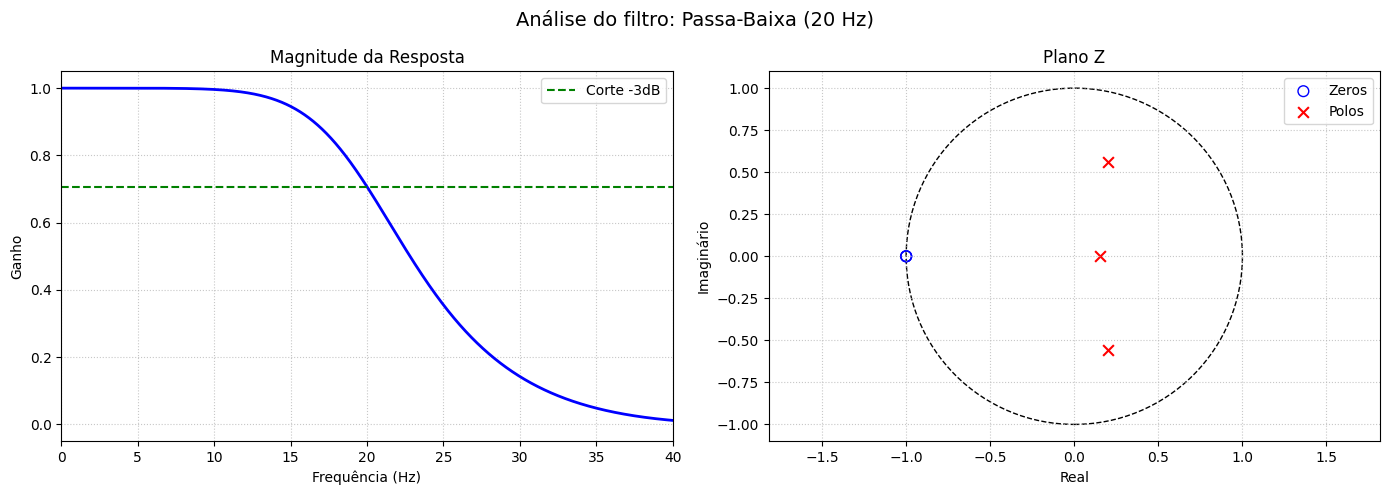

In [ ]:
# definir ordem do filtro e vizualização do filtro
ordem_filtro = 3
fc_baixa = 20.0

# gera os coeficientes globais do passa baixa
b_lp, a_lp = filtro_passa_baixa_alta(fc_baixa, fs, 'low', ordem_filtro)

# plota as caracteristicas do passa baixa
plot_caract_filtro(b_lp, a_lp, fs, 'Passa-Baixa (20 Hz)', f_limite=40)


###**3.3. Projeto do Filtro Passa-Alta (isolar gravidade)**

Após a eliminação do ruido, precisamos lidar com a força constante da gravidade. Como discutido anteriormente, a frequência é proximo de zero por ser constante.

Para remover a influência e isolar apenas movimentos humanos, deixaremos o filtro passa alta com faixa de corte em 0.3 Hz. Qualquer frequencia abaixo dela será barrado.

Nesta etapa, provamos:

* **Resposta em frequência:** O filtro barra frequências abaixo de 0.3 hz.

* **Polos e zeros:** O filtro projetado é matematicamente estável (todos os polos estão contidos dentro do círculo unitário no plano Z)




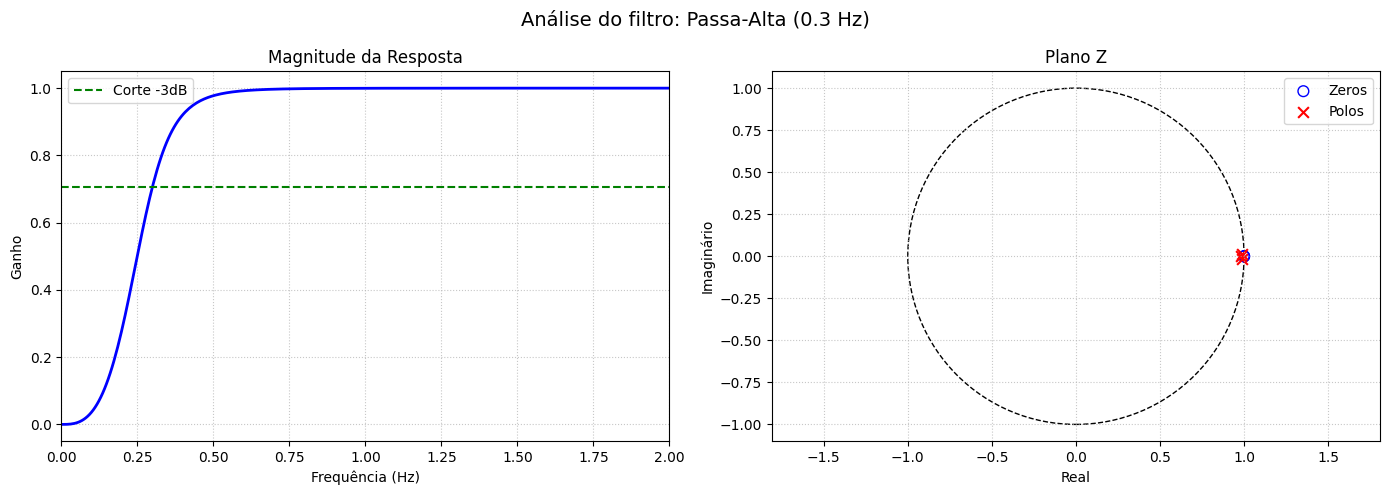

In [ ]:
fc_alta = 0.3
b_hp, a_hp = filtro_passa_baixa_alta(fc_alta, fs, 'high', ordem_filtro)
plot_caract_filtro(b_hp, a_hp, fs, 'Passa-Alta (0.3 Hz)', f_limite=2)

### **3.4. Aplicação dos filtros**

Os filtros projetados são aplicados sequencialmente a cada eixo (x, y e z) do acelerômetro. A função scipy.signal.filtfilt é utilizada para processar os dados nos sentidos direto e reverso, o que anula a distorção de fase e evita o deslocamento dos picos de movimento

In [ ]:
df_filtrado = df.copy()
eixos = ['accX_counts', 'accY_counts', 'accZ_counts']
for eixo in eixos:
  sinal_bruto = df[eixo].values

  #remove ruido de alta frequencia (acima de 20 hz)
  sinal_filtrado = signal.filtfilt(b_hp, a_hp, sinal_bruto)

  # remove o sinal de baixa frequencia (abaixo de 0.3 hz)
  sinal_acela_corpo = signal.filtfilt(b_lp, a_lp, sinal_filtrado)

  nome_col_nova = eixo.replace('counts', 'filt')
  df_filtrado[nome_col_nova] = sinal_acela_corpo


###**3.5. Análise comparativa: Sinais brutos vs Filtrados**

A eficácia do pipeline de filtragem deve ser atestada. A célula abaixo seleciona um eixo (o eixo X)  para plotar a comparação direta no dominio do tempo (para atestar a remoção dos ruidos) e no dominio da frequência utilizando a transformada Rápida de Fourier (FFT), evidenciando a supressão das bandas desejadas.

In [ ]:
display(df_filtrado.head())

,time_s,accX_counts,accY_counts,accZ_counts,comportamento,accX_filt,accY_filt,accZ_filt
0,0.001171,-15384,860,3956,caminhada,44.179034,-100.836127,88.883195
1,0.011568,-15204,852,3876,caminhada,118.780218,-96.274248,-32.245428
2,0.021852,-15400,852,3644,caminhada,135.249132,-111.871910,-133.965503
3,0.032104,-15280,832,3704,caminhada,81.290442,-149.886165,-217.782847
4,0.042358,-15452,744,3544,caminhada,-11.969606,-188.382583,-298.237491


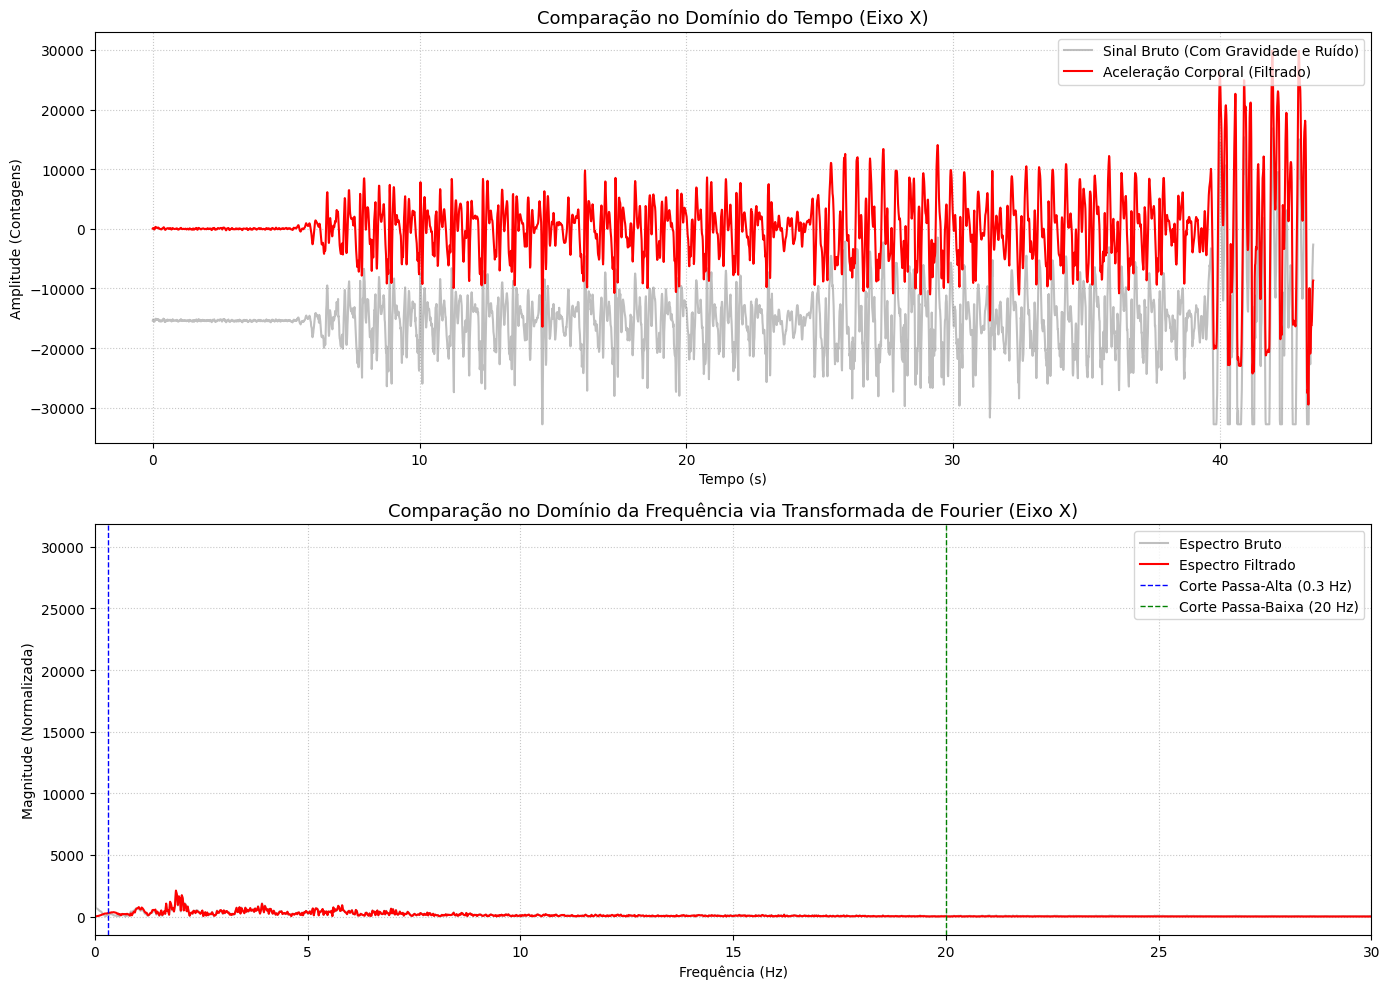

In [ ]:
def computar_espectro_fft (sinal, taxa_amostragem):
  """ Calcula a FFT e retorna as frequencias e magnitudes """

  n_amostras = len(sinal)
  frequencias = np.fft.rfftfreq(n_amostras, d=1/taxa_amostragem)

  # normalização da magnitude

  magnitudes = np.abs(np.fft.rfft(sinal)) * (2.0/n_amostras)

  return frequencias, magnitudes

# seleciona eixo X para demonstração

eixo_teste_bruto = 'accX_counts'
eixo_teste_filtrado = 'accX_filt'

temp = df_filtrado['time_s'].values
x_bruto = df_filtrado[eixo_teste_bruto].values
x_filtrado = df_filtrado[eixo_teste_filtrado].values

# calculo FFT
freq_orig, mag_orig = computar_espectro_fft(x_bruto, fs)
freq_proc, mag_proc = computar_espectro_fft(x_filtrado, fs)

fig, axs = plt.subplots(2, 1, figsize=(14, 10))

# plotagem dominio do tempo
axs[0].plot(temp, x_bruto, label='Sinal Bruto (Com Gravidade e Ruído)', color='gray', alpha=0.5)
axs[0].plot(temp, x_filtrado, label='Aceleração Corporal (Filtrado)', color='red', linewidth=1.5)
axs[0].set_title('Comparação no Domínio do Tempo (Eixo X)', fontsize=13)
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Amplitude (Contagens)')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle=':', alpha=0.7)

#plotagem dominio da frequencia
axs[1].plot(freq_orig, mag_orig, label='Espectro Bruto', color='gray', alpha=0.5)
axs[1].plot(freq_proc, mag_proc, label='Espectro Filtrado', color='red', linewidth=1.5)
axs[1].axvline(0.3, color='blue', linestyle='--', linewidth=1, label='Corte Passa-Alta (0.3 Hz)')
axs[1].axvline(20.0, color='green', linestyle='--', linewidth=1, label='Corte Passa-Baixa (20 Hz)')
axs[1].set_title('Comparação no Domínio da Frequência via Transformada de Fourier (Eixo X)', fontsize=13)
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (Normalizada)')
axs[1].set_xlim(0, 30) # Limita a visualização até 30 Hz para melhor inspeção
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


##**4. Segmentação dos dados (janelamento)**

###**4.1. Fundamentação dos Parâmetros**



* **Análise Empírica dos ciclos de movimento:**

  Foram pego amostras de tempo para fazer 2 passos completos (caminhada e corrida) e saltos completos no video, para cada evento, foi calculado uma média. Sendo:
  * **Caminhada:** Um ciclo Completo (2 passos) exigiu entre 1.15 e 1.18 segundos em média. Logo, a frequência de locomoção é de $\approx 1.74$ passos por segundo e a frequencia de locomoção em media 0.85 hz

  * **Corrida:** Um ciclo completo (2 passos) exigiu em média 0.67 segundos. Logo, a frequência de locomoção é de $\approx 2.98$ passos por segundo.

  * **Salto:** A execução de cada  salto (5 saltos) durou em média 0.38 segundos cada.


* **tamanho da Janela ($N_w$):** O ciclo mais longo registrado é o da caminhada (1.18 segundos). Se a janela temporal fosse inferior a esse valor, o algoritmo processaria frações de passo, impossibilitando a detecção do padrão cíclico.

Como a duração do bloco rotulado para salto corresponde, em média, a 109 amostras (considerando $f_s \approx 100$ hz), uma janela deslizantes excessivamente longa (2.56s) faria com que o evento de salto perdesse a maioria dentro do bloco, sendo estatisticamente ocultado na etapa de rotulagem.

Em razão disso, adotou-se uma janela de 128 amostras ($\approx 1.28$s). Esse comprimento acomoda um ciclo integral da caminhada, permite que um evento de salto ocupe uma fração dominante na matriz (garante sua detecção) e consistente em uma potência de base 2, o que otimiza computacionalmente a FFT.

* **Superposição (Overlap):** adotou-se o avanço de apenas 32 amostras (taxa de sobreposição de 75%) entre janelas consecutivas. A adoção desse parâmetro baseia-se em duas justificativas:

  * **Mitigar o efeito de borda:** Previne a fragmentação do sinal. Se um passo ou salto ocorrer exatamente na transição entre duas janelas, o overlap assegura que esse movimento estará centrado na janela subsequente.


  * **Compensação da classe minoritária:** O experimento fisico com o acelerômetro registrou a ocorrência de apenas 5 saltos, totalizando 545 amostras rotuladas. Uma taxa de sobreposição tradicional (50%) mostrou-se insuficientes para gerar um volume de instâncias capaz de sustentar a validação cruzada sem induzir ao colapso das métricas (o número de instâncias ficaria 8, foi testado com 8, a precisão foi relativamente baixa e o desvio padrão muito alto (na casa de 0.16-0.17)). Após pesquisas na literatura de HAR, os estudos estabelecem que  75% é um limite superior seguro de sobreposição. No contexto do projeto, esse valor maximiza a densidade de amostras extraidos, levando a uma robustez maior nos classificadores, sem cruzar a fronterira que causaria vazamento de dados.

  A dimensionalidade sinal da matriz de dados obedece à equação do janelamento:

  $$N_{janelas} = \lfloor \frac{N_{total} - N_{w}}{passo} \rfloor + 1$$

  Sendo que:

    **$N_{janelas}$**: número de janelas

    **$N_{total}:$** Comprimento total do sinal (total de amostras)

    **$N_{w}$:** Tamanho da janela

    **$passo:$** Deslocamento a cada passo. É o tamanho da janela subtraido da sobreposição (número de amostras)

    No contexto do projeto, 75% (sobreposição) de 128 (tamanho da janela) em número de amostras corresponde a 96. Portanto, o deslocamento será de 32 amostras.




###**4.2. Implementação do algoritmo  de Sliding Window**

A celula a seguir implementa a segmentação. Para garantir a pureza dos dados de entrada do classificador, apenas os eixos contendo a aceleração corporal filtrada (livre de ruido e gravidade) serão particionados.

In [ ]:
import scipy.stats as stats

def segmentar_sinais (dados_features, dados_rotulos, tam_janela, passo):
  """ Aplica o algoritmo de janelamento deslizante sobre a matriz de dados
  e retorna uma lista de janelas e um vetor com rótulos"""

  janelas = []
  rotulos = []

  total_amostras = len(dados_features)

  for i in range(0, total_amostras - tam_janela + 1, passo):
    janela_atual = dados_features[i:i+tam_janela]
    rotulo_janela = dados_rotulos[i:i+tam_janela]

    # o rotulo da janela é a moda
    valores, contagens = np.unique(rotulo_janela, return_counts=True)
    rotulo_predominante = valores[np.argmax(contagens)]

    janelas.append(janela_atual)
    rotulos.append(rotulo_predominante)

  return np.array(janelas), np.array(rotulos)

# definição dos parametros
TAM_JANELA = 128 # amostras (aprox. 1,28s)
OVERLAP = 32 # amostras (avanço 75%)

col_corpo = ['accX_filt', 'accY_filt', 'accZ_filt']
matriz_sinais = df_filtrado[col_corpo].values
vetor_comportamento = df_filtrado['comportamento'].values


X_janelas, y_janelas = segmentar_sinais(matriz_sinais, vetor_comportamento, TAM_JANELA, OVERLAP)

print(f"Total de janelas: {X_janelas.shape}")
print(f"Total de rótulos: {y_janelas.shape}")

# verificação do balanceamento de classes após o janelamento
classes, contagens = np.unique(y_janelas, return_counts=True)

for x, freq in zip(classes, contagens):
  percentual = (freq / len(y_janelas)) * 100
  print(f"{x}: {freq} ({percentual:.2f}%)")

Total de janelas: (131, 128, 3)
Total de rótulos: (131,)
caminhada: 70 (53.44%)
corrida: 46 (35.11%)
salto: 15 (11.45%)


##**5. Extração de características**

###**5.1. Definição matemática das features**

A etapa de extração de características transforma as janelas temporais de dados brutos em um vetor de atributos numéricos.

Para cada um dos 3 eixos (x, y e z) contidos em uma janela de observação, são calculadas cinco métricas estatísticas e espectrais:

  * **Média:** Computa a tendência central do sinal na janela. Como o filtro passa-alta (0.3 Hz) aplicado no tópico 3 removeu a gravidade (DC), espera-se que a média da aceleração dinâmica  tenda a zero.

  * **Desvio Padrão:** Quantifica a dispersão dos dados em torno da média. Em termos físicos, representa a intensidade ou a energia mecânica bruta da atividade. Uma janela deslizante contendo a transição de um "salto" apresentará um desvio padrão muito maior do que uma janela de "caminhada".

  * **Coeficiente de Fourier:** O sinal temporal é convertido para o domínio da frequência via FFT. A extração da magnitude máxima desses coeficientes (excluindo a componente DC) captura a cadência predominante e a frequência fundamental do movimento, diferenciando os espectros de passos rápidos (corrida) e passos lentos (caminhada).

  * **Autocorrelação:** Mede a correlação do sinal consigo mesmo após sucessivos deslocamentos no tempo. Movimentos cíclicos contínuos e simétricos geram padrões de autocorrelação com picos periódicos bem definido, diferindo de eventos explosivos e isolados (como salto). A feature extraída é a média das correlações em deslocamentos positivos (pra direita).

  * **Entropia espectral:** Baseada na teoria da informação de Shannon, quantifica o grau de incerteza/desordem do sinal baseando-se em sua Densidade Espectral de Potencia (DEP). Uma caminhada retilínea em ritmo constante concentra sua energia em poucas frequências, gerando um sinal previsível (baixa entropia, pois tem maior organização). Em contrapartida, as fases de impacto e transição geométrica abrupta presentes na corrida e no salto espalham a energia por múltiplas bandas, resultando em alta entropia (maior desorganização).






###**5.2. Implementação das funções de extração**

A implementação foi estruturada de forma modular através de uma função principal que recebe uma única janela de observação (contendo 128 amostras e 3 eixos) e retorna o valor unidimensional comprimido.


O laço de repetição interno itera sobre os eixos x, y e z isoladamente. Para cada eixo, o programa calcula a média, o desvio padrão, a magnitude do pico de fourier, a autocorrelação e a entropia espectral. O resultado final dessa função é a conversão estrutural de uma matriz de 128x3 em um vetor no plano contendo exatamente 15 características (features)

In [ ]:
def calcular_entropia_espectral (sinal):
  """ Calcula a entropia espectral de um sinal"""
  # calcula DEP
  dep = np.abs(np.fft.rfft(sinal))**2

  # previne inderterminação caso o sinal seja nulo
  soma_dep = np.sum(dep)
  if soma_dep == 0:
    return 0.0

  # normaliza a dep para criar uma distribuição de probabilidade (FDP)
  dep_norm = dep/soma_dep

  # calcula a entropia de shannon em base 2
  return entropy(dep_norm, base=2)

def extrair_features_janela (janela):
  features_vetor = []
  # itera sobre os canais espaciais 0 (x) 1 (y) e 2 (z)
  for eixo in range(3):
    sinal_eixo = janela[:, eixo]

    # média
    media = np.mean(sinal_eixo)

    # devio padrão
    desvio_padrao = np.std(sinal_eixo)

    # coeficiente de fourier
    fourier = np.abs(np.fft.rfft(sinal_eixo))
    fourier_mag = np.max(fourier[1:]) if len(fourier) > 1 else 0.0

    # autocorrelação
    autocorr = np.correlate(sinal_eixo, sinal_eixo, mode='full')
    autocorr_positiva = autocorr[len(autocorr) // 2:]
    autocorr_media = np.mean(autocorr_positiva)

    # entropia espectral
    entropia_espectral = calcular_entropia_espectral(sinal_eixo)

    features_vetor.extend([media, desvio_padrao, fourier_mag, autocorr_media, entropia_espectral])

  return features_vetor


###**5.3. Construção da matriz de dados (X) e vetor de rótulos (y)**

Nessa etapa, a função de extração de características é aplicada de forma global sobre todo o conjunto de dados segmentados. O pipeline percorre o tensor tridimensional de janelas (gerado na etapa de segmentação) e processa cada bloco de forma independente.

A execução desses vetores resultantes forma a matriz bidimensional de variáveis independentes (X), onde cada linha representa uma instancia de tempo (janela) e cada coluna representa um atributo. O vetor unidimensional de variáveis dependentes (y) é alinhado simetricamente à matriz X para preservar o rótulo de classe (caminhada, corrida e  salto) de cada instância.

In [ ]:
#inicializa a lista pra armazenar os vetores de features
matriz_features = []

# aplica o extrator sobre cada instância do tensor de janelas
for janela in X_janelas:
  features_janela = extrair_features_janela(janela)
  matriz_features.append(features_janela)

# consolida a matriz de variáveis independentes (X) e dependentes (y)
X_dados = np.array(matriz_features)
y_rotulos = y_janelas

print(f"Tamanho da matriz de dados (X): {X_dados.shape}")
print(f"Tamanho do vetor de rotulos (y): {y_rotulos.shape}")


# estruturação do dataframe para validação tabular
nomes_colunas = [
    f"{metrica}_{eixo}" for eixo in ['accX_filt', 'accY_filt', 'accZ_filt']
    for metrica in ['Media', 'Desvio_Padrao', 'FFT_Pico', 'Autocorr', 'Entropia']
]

df_features = pd.DataFrame(X_dados, columns=nomes_colunas)
df_features['comportamento'] = y_rotulos

# exibe as 5 primeiras lihas

display(df_features.head())

Tamanho da matriz de dados (X): (131, 15)
Tamanho do vetor de rotulos (y): (131,)


,Media_accX_filt,Desvio_Padrao_accX_filt,FFT_Pico_accX_filt,Autocorr_accX_filt,Entropia_accX_filt,Media_accY_filt,Desvio_Padrao_accY_filt,FFT_Pico_accY_filt,Autocorr_accY_filt,Entropia_accY_filt,Media_accZ_filt,Desvio_Padrao_accZ_filt,FFT_Pico_accZ_filt,Autocorr_accZ_filt,Entropia_accZ_filt,comportamento
0,29.723445,100.419833,3349.590099,62026.735511,4.021557,-40.357280,114.949177,5442.748896,111658.453724,3.200290,-76.003964,205.823918,15732.873547,393772.610031,2.283488,caminhada
1,0.382255,84.165746,3129.474885,3551.361011,4.218564,19.930396,80.518764,3490.231687,28862.371143,3.775182,-69.012876,209.308635,13911.195740,329104.170586,2.874449,caminhada
2,-7.578755,73.418730,2327.214210,6399.875664,4.150602,33.374633,68.197371,2687.275387,74169.804384,3.608284,-15.782419,221.034832,11785.077352,40494.165434,2.913936,caminhada
3,-9.490119,73.023258,2661.279416,8475.219872,4.280910,28.870173,69.914674,3168.493217,56203.934246,3.658865,2.478230,224.116545,11927.445981,25510.247760,2.901244,caminhada
4,-0.412005,84.232717,2845.066085,3558.524077,4.122324,-41.929894,137.185252,7002.393124,122808.381505,3.389460,76.735769,232.579460,15665.333273,406846.995808,2.934547,caminhada


##**6. Classificação e validação**

###**6.1. Metodologia de validação e configuração dos modelos**

A matriz de características extraída na etapa anterior apresenta grandezas de escalas numéricas distintas (ex: média oscila em torno de zero e autocorrelação na ordem de milhares). Os modelos baseados no cálculo de distâncias geométricas (nesse caso, a Máquina de Vetires de Suporte (SVM)) são enviesados por grandezas maiores. Para anular essa distorção, exige-se a padronização das variáveis independentes (X) para que assumam média zero e variância unitária.

Para a avaliação estrutural da capacidade de generalização dos modelos, descarta-se a divisão simples de treino e teste, adotando-se o método de Validação cruzada Estratificada (Stratified K-fold). O parâmetro de partições (k) será definido como 5. Sabendo que a classe minoritária (salto) detém 15 instâncias totais, a configuração k = 5 assegura que todas as 5 bases de testes concebidas contenham ao menos 1 amostra de salto. A estratificação preserva a proporção exata da distribuição original das classes, configurando um ambiente de testes imparcial e funcional contra o overfitting

Três arquiteturas distintas de ML são instânciadas para estabelecer uma base comparativa:

* **Support Vector Machine (SVM):** Configurado com o kernel RBF (radial basis function), que atua projetando o espaço de características linearmente inseparável em dimensões superiores, otimizando o hiperplano de separação das três atividades.

* **Random Forest:** Um conjunto (ensemble) de árvores de decisão. Opera por particionamento ortogonal do espaço de características e apresenta alta tolerância aos ruídos ou dados discrepantes (outliers) residuais da filtragem.

* **XGBoost:*** Fundamentado no impulsionamento por gradiente (gradient boosting).Esse modelo exige estritamente que o vetor alvo (y) esteja em formato de número inteiro. Consequentemente, as categorias (caminhada, corrida e salto) serão codificadas para valores numéricos ordenados através de uma função de codificação de rótulos.

###**6.2. Treinamento e avaliação dos modelos**

A performance de cada iteração será medida utilizando o Escore F1 Macro. Em conjuntos de dados com grande desbalanceamento,  a acurácia global falha ao mascarar o erro das classes minoritárias. O escore F1 Macro calcula a média  entre a precisão e o recall isoladamente para cada classe e extrai a média não ponderada final, tratando tanto "salto" (classe de menor número de amostras) quanto "caminhada" (classe com maior número de amostras) com o mesmo grau de importância.

####**6.2.1. Preparação global do ambiente de validação**

Antes de instânciar os modelos, os rótulos de texto são convertido para valores numéricos e o particionador estratificado é definido.

In [ ]:
# preparação da matriz de dados e vetor alvo
X = df_features.drop('comportamento', axis=1).values
y_categorico = df_features['comportamento'].values

# Deixar em valores numericos em vez de string
encoder = LabelEncoder()
y = encoder.fit_transform(y_categorico)

# exibe o mapeamento das classes gerado pelo encoder
mapeamento_classes = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(mapeamento_classes)

# configuração da validação cruzada com k = 5
validador_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_f1 = {}



{'caminhada': np.int64(0), 'corrida': np.int64(1), 'salto': np.int64(2)}


####**6.2.2. Treinamento e avaliação do SVM**

In [ ]:
# construção do pipeline
pipeline_svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))

# validação cruzada
escores_svm = cross_val_score(pipeline_svm, X, y, cv=validador_cv, scoring='f1_macro')
resultados_f1['SVM'] = escores_svm

print(f"Escores F1 Macro SVM: {np.round(escores_svm, 4)}")
print(f"Média F1 Macro SVM: {np.mean(escores_svm):.4f}")
print(f"Desvio padrão F1 Macro SVM: {np.std(escores_svm):.4f}")


Escores F1 Macro SVM: [0.6703 0.7648 0.7741 0.7462 0.8631]
Média F1 Macro SVM: 0.7637
Desvio padrão F1 Macro SVM: 0.0617


####**6.2.3. Treinamento e avaliação do Random Forest**

In [ ]:
# construção do pipeline
pipeline_rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))

# validação cruzada
escore_rf = cross_val_score(pipeline_rf, X, y, cv=validador_cv, scoring='f1_macro')
resultados_f1['Random Forest'] = escore_rf

print(f"Escores F1 Macro Random Forest: {np.round(escore_rf, 4)}")
print(f"Média Random Forest: {np.mean(escore_rf):.4f}")
print(f"Desvio padrão Random Forest: {np.std(escore_rf):.4f}")

Escores F1 Macro Random Forest: [0.8322 0.8523 0.7815 0.7741 0.8351]
Média Random Forest: 0.8150
Desvio padrão Random Forest: 0.0313


####**6.2.4. Treinamento e avaliação do XGBoost**

In [ ]:
# construção do pipeline
pipeline_xgb = make_pipeline(StandardScaler(), XGBClassifier(eval_metric='mlogloss', random_state=42))

# validação cruzada
escore_xgb = cross_val_score(pipeline_xgb, X, y, cv=validador_cv, scoring='f1_macro')
resultados_f1['XGBoost'] = escore_xgb

print(f"Escores F1 Macro XGBoost: {np.round(escore_xgb, 4)}")
print(f"Média XGBoost: {np.mean(escore_xgb):.4f}")
print(f"Desvio padrão XGBoost: {np.std(escore_xgb):.4f}")


Escores F1 Macro XGBoost: [0.8609 0.8594 0.7815 0.7462 0.9103]
Média XGBoost: 0.8317
Desvio padrão XGBoost: 0.0594


##**7. Análise de resultados**

Para uma avaliação visual dos resultados, a análise é dividida em duas partes: a variância das métricas (box plots) e o mapeamento de erros (matriz de confusão).

###**7.1. Visualização de desempenho (Box Plots)**

Box plots é utilizado para evidenciar não somente a mediana de acertos de cada modelo, mas também a dispersão (variância) do escore F1 ao longo dos 5 folds de teste.

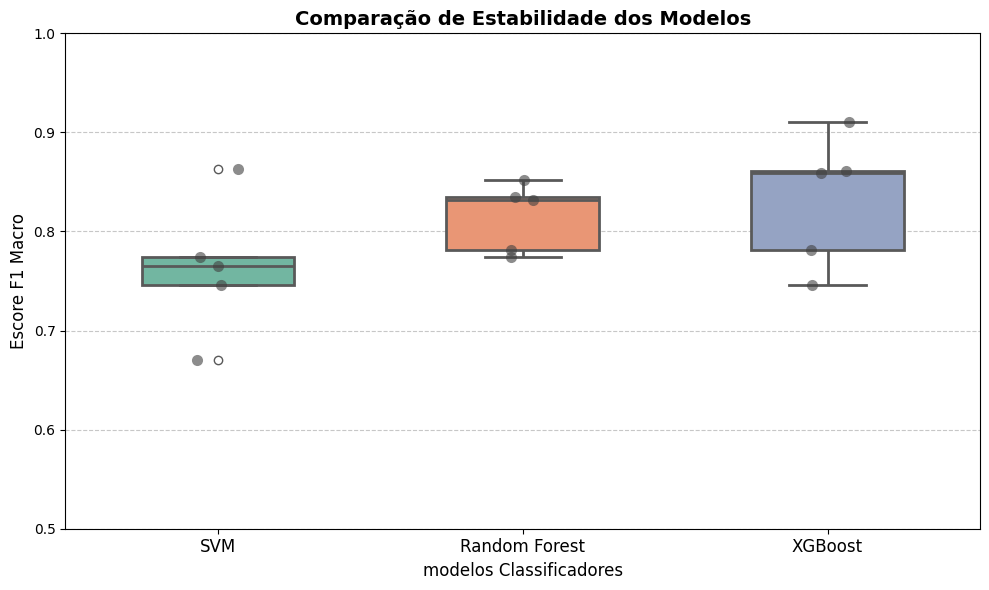

In [ ]:
# extrai os nomes dos modelos e seus arrays de resultados (5 scores cada)
nomes_modelos = list(resultados_f1.keys())
resultados_modelos = list(resultados_f1.values())

plt.figure(figsize=(10, 6))

#construção do box plots
sns.boxplot(data=resultados_modelos, palette="Set2", width=0.5, linewidth=2)
sns.stripplot(data=resultados_modelos, color='.25', size=8, alpha=0.6, jitter=True)

plt.xticks(ticks=range(len(nomes_modelos)), labels=nomes_modelos, fontsize=12)
plt.title('Comparação de Estabilidade dos Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Escore F1 Macro', fontsize=12)
plt.xlabel('modelos Classificadores', fontsize=12)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


**Analise do desempenho**

A análise dos classificadores revela os seguintes comportamentos:

  * **Support Vector Machine (SVM)**

      O modelo apresentou o desempenho mais modesto.
      
      O itervalo interquartil se concentra na faixa inferior do gráfico. Além disso, o modelo apresenta instabilidade nos extremos, tendo picos próximos a 90% mas também quedas próximos de 70%.

      Isso indica que o SVM é altamente sensível e dependente de quais amostras compõe a base de treino, demonstrando dificuldade na generalização.

  * **Random Forest**

      O modelo apresentou a maior consistência e estabilidade global dentre todos.

      Apresentando relativamente pouca variação, sendo consistente nos valores mais altos de precisão, sendo que, os valores giram ao redor de 80%. O modelo mantém a estabilidade (devido menor variância) ao mesmo tempo em que mantém uma precisão quase tão grande quanto o xgboost.

  * **XGBoost**

      Apesar do modelo possuir uma variância maior do que o Random Forest, ele apresenta como um todo um maior teto preditivo e maior mediana.

      Analisando o gráfico, os pontos do xgboost posicionam-se nas partes mais altas,  em torno de 85%, com o pico e a mediana sendo os maiores dentre os 2 outros modelos.
      Entretanto, é importante ressaltar que ele possui um ponto na qual tem uma precisão relativamente baixa, em torno de 74%.


  Conclui-se que o XGBoost é o melhor modelo em termos de acurácia (melhor predição geral). Entretanto, em um cenário prático de implementação, o Random Forest se destaca como uma escolha mais segura e estável.

###**7.2 Matrizes de confusão**

A matriz de confusão expõe de forma visual as métricas de como foram as classificações dos modelos. Cruzando as previsões com os rótulos verdadeiros definidos.


Para isso, utiliza a função cross_val_predict. Ela realiza a divisão de 5 partições, mas em vez de retornar apenas a nota final, ela retorna a predição feita para cada uma das 131 janelas quando elas estiverem na base de teste.

####**7.2.1. Matriz de confusão SVM**

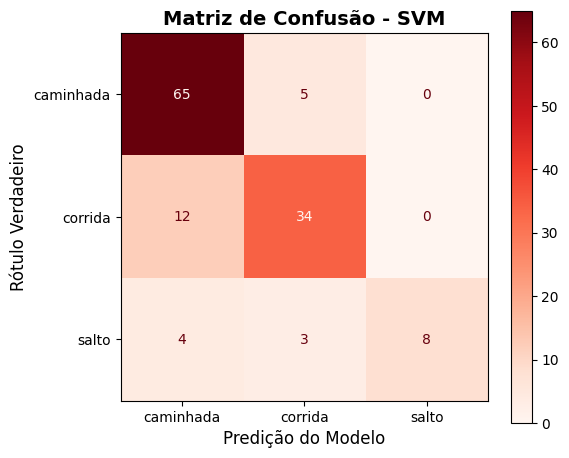

In [ ]:
#recupera os nomes originais das classes numéricas
nomes_classes = encoder.classes_

# gera as predições para todo dataset
y_predito_svm = cross_val_predict(pipeline_svm, X, y, cv=validador_cv)

# calcular a matriz de confusão
matriz_confusao_svm = confusion_matrix(y, y_predito_svm)

# plotagem
plt.figure(figsize=(6, 5))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_svm, display_labels=nomes_classes)
disp_svm.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()


**Análise**

O modelo apresenta um comportamento "conservador", tendendo a subestimar a intensidade do movimento.

O SVM acertou 65 das 70 "caminhadas", mas apresentou grande dificuldade na classe "corrida", classificando 12 corridas como caminhadas. Em relação à classe "salto", o SVM acertou um pouco mais da metade (8 de 15), diluindo o restante entre caminhada e corrida. Isso evidencia que o modelo não conseguiu traçar uma fronteira clara de separação.

####**7.2.2. Matriz de confusão - Random Forest**

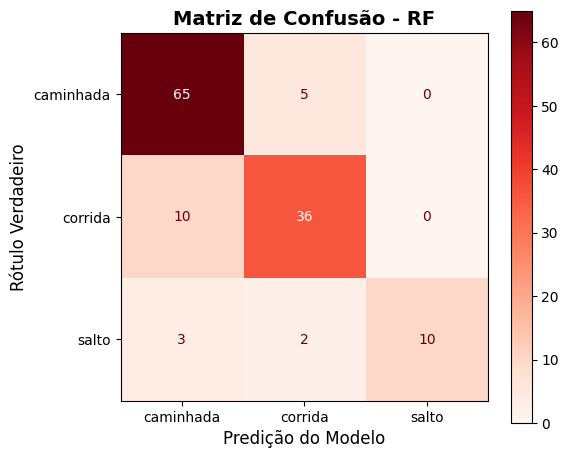

In [ ]:
# gera as predições para o random forest
y_predito_rf = cross_val_predict(pipeline_rf, X, y, cv=validador_cv)

# calcular a matriz de confusão
matriz_confusao_rf = confusion_matrix(y, y_predito_rf)

# plotagem
plt.figure(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_rf, display_labels=nomes_classes)
disp_rf.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - RF', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()


**Análise**

O particionamento ortogonal das árvores de decisão elevaram a precisão das classes de maior energia (correr e pular).

A classificação correta de "salto" subiu de 8 para 10 instâncias. O erro na classe corrida" diminuiu (10 instâncias erradas, 2 a menos que o SVM) da mesma forma. Essa melhoria ocorre devido o Random Forest conseguir isolar regras específicas devido o algoritmo de árvore de decisão, lidando melhor com a sobreposição espectral dos dados do que o SVM.

####**7.2.3 Matriz de confusão - XGBoost**

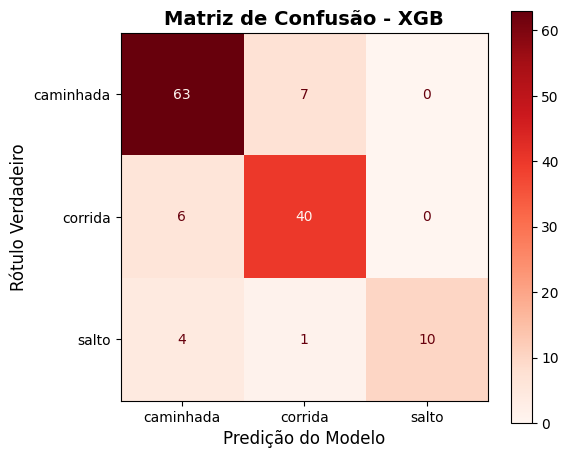

In [ ]:
# gera as predições para o random forest
y_predito_xgb = cross_val_predict(pipeline_xgb, X, y, cv=validador_cv)

# calcular a matriz de confusão
matriz_confusao_xgb = confusion_matrix(y, y_predito_xgb)

# plotagem
plt.figure(figsize=(6, 5))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_xgb, display_labels=nomes_classes)
disp_xgb.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - XGB', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()


**Análise**

O algoritmo de gradient boosting (xgboost) demonstrou a maior capacidade de distinguir a transição entre caminhar e correr.

O modelo atingiu o maior montante de acertos na classe "corrida" (40 de 46) e manteve os 10 acertos da classe "salto". Entretanto, teve uma leve queda de acertos na classe "caminhada" (confundiu 7 instâncias com corrida, 2 instâncias a mais que os outros modelos).

##**8. Conclusão**

A execução do projeto demonstrou a eficácia da integração entre as técnicas de processamento digital de sinais (PDS) aprendidos em sala de aula e os modelos de Aprendizado de Máquina para a resolução do problema de Reconhecimento de Atividades Humanas (HAR). A transição dos dados brutos para um modelo preditivo exigiu a superação de desafios, que foram superados no decorrer do desenvolvimento.

Abaixo serão abordados uma análise conclusiva sobre o projeto:

  * **Eficácia do pré-processamento e filtragem**
      
      A aplicação em cascata dos filtros Butterwoth provou-se estruturalmente essencial. O filtro passa-alta (corta frequências abaixo de 0.3 hz) eliminou o vetor constante da gravidade, enquanto o passa-baixa (corta frequências acima de 20 hz) suprimiu ruídos de alta frequência. A verificação visual no dominio da frequência atestou que as bandas de passagem foram respeitadas (ausência de ripple), entregando aos modelos de classificação apenas os movimentos humanos puros.

  * **Impacto estrutural da segmentação**

      O janelamento deslizante exigiu uma atenção rigorosa para contornar o problema de déficit de amostragem. A elevação da taxa de sobreposição (overlap), anteriormente como 50%,  para 75% (limite superior seguro para HAR) elevou a captura da classe minoritária (salto) de 8 (overlap de 50%) para 15 instâncias (overlap de 75%). Essa adequação evitou o colapso do escore F1 Macro durante a validação cruzada, provando que a estabilidade de qualquer modelo depende essencialmente do volume de dados injetados no treinamento e teste.

  * **Avaliação do espaço de características**

     A etapa de extração de características foi de extrema importância para traduzir a série temporal em um formato interpretável pelos modelos classificadores de Machine Learning. A conversão das matrizes tridimensionais (128 amostras em 3 eixos) em vetores unidimensionais de 15 atributos operou uma redução de dimensionalidade. O cálculo das métricas estatísticas (média, autocorrelação e desvio padrão) e espectrais (pico de fourier e  entropia espectral) permitiu mapear numericamente o padrão de dispersão, a periodicidade estrutural e as frequências fundamentais de cada movimento. Como resultado, o espaço de características apresentou um alto grau de separabilidade.

  

  * **Desempenho dos classificadores (modelos)**

      As predições variaram conforme a estrutura do modelo (algoritmo):

      - **SVM**: apresentou limitações na construção de hiperplanos eficientes para dados com sobreposição espectral, o que acarretou na métrica mais baixa em desempenho dos modelos.

      - **Random Forest:** demonstrou a maior consistência estatísticamente (como visto no box plot). O modelo de árvore de decisão neutralizou o efeito de variações isoladas nos dados de teste, traduzindo-se em uma alta precisão acompanhada da menor variância (sendo a menor entre os modelos).

      - **XGBoost:** foi o modelo que  entregou o melhor desempenho na métrica F1 Macro (em média). O modelo de gradiente boosting discriminou com o maior grau de precisão  a transição entre eventos (caminhada, corrida e salto), sendo o modelo com o maior teto de precisão.